In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 14.56 GB


In [ ]:
!pip install -q -U \
    transformers \
    accelerate \
    peft \
    bitsandbytes \
    datasets \
    qwen-vl-utils \
    jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 18.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/largelisanmodel"
)

TRAIN_FILE = (
    PROJECT_ROOT
    / "dataset_qwen"
    / "train.jsonl"
)

VAL_FILE = (
    PROJECT_ROOT
    / "dataset_qwen"
    / "val.jsonl"
)

TEST_FILE = (
    PROJECT_ROOT
    / "dataset_qwen"
    / "test.jsonl"
)

print("Project:", PROJECT_ROOT)
print("Train:", TRAIN_FILE.exists())
print("Val:", VAL_FILE.exists())
print("Test:", TEST_FILE.exists())

Project: /content/drive/MyDrive/largelisanmodel
Train: True
Val: True
Test: True


In [ ]:
import json

def load_jsonl(path):
    records = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))

    return records


train_records = load_jsonl(TRAIN_FILE)
val_records = load_jsonl(VAL_FILE)
test_records = load_jsonl(TEST_FILE)

print("Full train:", len(train_records))
print("Full val:", len(val_records))
print("Full test:", len(test_records))

Full train: 3955
Full val: 465
Full test: 234


In [ ]:
TRAIN_SIZE = 100
VAL_SIZE = 20

small_train_records = train_records[:TRAIN_SIZE]
small_val_records = val_records[:VAL_SIZE]

print("Debug train:", len(small_train_records))
print("Debug val:", len(small_val_records))

Debug train: 100
Debug val: 20


In [ ]:
SPECIAL_CHAR = "\uE001"

def find_special_samples(records, split_name):
    matches = []

    for i, record in enumerate(records):
        target = record["messages"][1]["content"][0]["text"]

        if SPECIAL_CHAR in target:
            image_path = record["messages"][0]["content"][0]["image"]

            matches.append({
                "index": i,
                "split": split_name,
                "image": image_path,
                "text": target,
                "count": target.count(SPECIAL_CHAR)
            })

    return matches


special_samples = (
    find_special_samples(small_train_records, "train")
    + find_special_samples(small_val_records, "val")
    # + find_special_samples(test_records, "test")
)

print("Samples containing U+E001:", len(special_samples))

for sample in special_samples[:20]:
    print(
        sample["split"],
        "| index:", sample["index"],
        "| count:", sample["count"],
        "|", sample["image"],
        "|", repr(sample["text"])
    )

Samples containing U+E001: 8
train | index: 27 | count: 1 | dataset/images/train_000028_v01.png | 'ام سلمة ك\ue001ے ؛'
train | index: 31 | count: 1 | dataset/images/train_000032_v01.png | 'يه مولانا عبد علي سيف الدين يه عجب شان سي اْپنا بعد 4 دعاة قائم تهاےس اهني تم\ue001يد كيدي،'
train | index: 51 | count: 1 | dataset/images/train_000052_v01.png | 'يه پوتانے أيك گهرٌي بهي اهنا مستحق نه سمجها بلكه ايم} ك\ue001تا كه ميں ادنى چهوں منے بخشي دو!'
train | index: 53 | count: 1 | dataset/images/train_000054_v01.png | 'انے 8 ورس لگن اْپ رسول االله نا ساتهے انے مولاتنا خديجة جه رسول االله نا دُل\ue001ن ؛'
train | index: 55 | count: 1 | dataset/images/train_000056_v01.png | 'چوكهّا كپرٌا هوئي اْم نوا} لاگے اهوا كپرٌا پ\ue001نے،'
val | index: 0 | count: 1 | dataset/images/val_000001_v01.png | 'پ\ue001نچوانو ؛'
val | index: 11 | count: 1 | dataset/images/val_000012_v01.png | 'خصوصا اْج نا دن ما ماري دعاء ني بركة تمام مؤمنين مؤمنات طرف پ\ue001نچاؤجے،'
val | index: 14 | count: 1 | dataset/images/val

In [ ]:
def get_image_path(record):
    relative_path = (
        record["messages"][0]["content"][0]["image"]
    )

    return PROJECT_ROOT / relative_path


missing = []

for record in small_train_records:
    path = get_image_path(record)

    if not path.exists():
        missing.append(path)

print("Missing images:", len(missing))

for path in missing[:10]:
    print(path)

Missing images: 0


In [ ]:
sample = small_train_records[0]

print(
    json.dumps(
        sample,
        ensure_ascii=False,
        indent=2
    )
)

{
  "messages": [
    {
      "role": "user",
      "content": [
        {
          "type": "image",
          "image": "dataset/images/train_000001_v01.png"
        },
        {
          "type": "text",
          "text": "Transcribe the text in this image exactly. Preserve the original spelling, punctuation and characters. Do not translate, explain, correct or add any text. Return only the transcription."
        }
      ]
    },
    {
      "role": "assistant",
      "content": [
        {
          "type": "text",
          "text": "اْپنا دل ني انے جه قران اْپنا دل پر اترا يه سگلا ني معرفة كرينے حقيقة اْپني امة خالصة اپن سگلا؛،"
        }
      ]
    }
  ]
}


In [ ]:
target = sample["messages"][1]["content"][0]["text"]

print("Target:", target)
print(
    "Contains U+E001:",
    "\uE001" in target
)

Target: اْپنا دل ني انے جه قران اْپنا دل پر اترا يه سگلا ني معرفة كرينے حقيقة اْپني امة خالصة اپن سگلا؛،
Contains U+E001: False


In [ ]:
from transformers import AutoProcessor

MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"

processor = AutoProcessor.from_pretrained(
    MODEL_ID
)

tokenizer = processor.tokenizer

print("Processor loaded")
print("Tokenizer size:", len(tokenizer))

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Processor loaded
Tokenizer size: 151665


In [ ]:
from transformers import BitsAndBytesConfig

compute_dtype = (
    torch.bfloat16
    if torch.cuda.is_bf16_supported()
    else torch.float16
)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=True,
)

print("Compute dtype:", compute_dtype)

Compute dtype: torch.bfloat16


In [ ]:
from transformers import Qwen2_5_VLForConditionalGeneration

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map={"": 0},
    dtype=compute_dtype,
)

print("Qwen loaded")

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Qwen loaded


In [ ]:
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)

model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=True
)

model.config.use_cache = False

In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",

    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],

    task_type="CAUSAL_LM",
)

model = get_peft_model(
    model,
    lora_config
)

model.print_trainable_parameters()

trainable params: 37,152,768 || all params: 3,791,775,744 || trainable%: 0.9798


In [ ]:
import random

SPECIAL_CHAR = "\uE001"

special_train = []
normal_train = []

for record in train_records:
    target = record["messages"][1]["content"][0]["text"]

    if SPECIAL_CHAR in target:
        special_train.append(record)
    else:
        normal_train.append(record)

print("Special train samples:", len(special_train))
print("Normal train samples :", len(normal_train))

Special train samples: 378
Normal train samples : 3577


In [ ]:
random.seed(42)

NORMAL_COUNT = 80
SPECIAL_COUNT = 20

small_train_records = (
    random.sample(normal_train, NORMAL_COUNT)
    +
    random.sample(special_train, SPECIAL_COUNT)
)

random.shuffle(small_train_records)

print("Training samples:", len(small_train_records))

special_count = sum(
    SPECIAL_CHAR in r["messages"][1]["content"][0]["text"]
    for r in small_train_records
)

print("Containing U+E001:", special_count)

Training samples: 100
Containing U+E001: 20


In [ ]:
small_val_records = small_train_records

In [ ]:
def get_image_path(record):
    relative_path = record["messages"][0]["content"][0]["image"]
    return PROJECT_ROOT / relative_path


missing = []

for record in small_train_records:
    path = get_image_path(record)

    if not path.exists():
        missing.append(path)

print("Missing images:", len(missing))

for path in missing[:10]:
    print(path)

Missing images: 0


In [ ]:
normal_count = 0
special_count = 0
special_occurrences = 0

for record in small_train_records:
    target = record["messages"][1]["content"][0]["text"]

    if SPECIAL_CHAR in target:
        special_count += 1
        special_occurrences += target.count(SPECIAL_CHAR)
    else:
        normal_count += 1

print("Total samples        :", len(small_train_records))
print("Normal samples       :", normal_count)
print("U+E001 samples       :", special_count)
print("U+E001 occurrences   :", special_occurrences)

Total samples        : 100
Normal samples       : 80
U+E001 samples       : 20
U+E001 occurrences   : 24


In [ ]:
NUM_EPOCHS = 10
BATCH_SIZE = 1
GRAD_ACCUM = 4
LEARNING_RATE = 2e-4

In [ ]:
from torch.utils.data import Dataset

class QwenOCRDataset(Dataset):
    def __init__(self, records, project_root):
        self.records = records
        self.project_root = Path(project_root)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        record = self.records[idx]

        image_rel = record["messages"][0]["content"][0]["image"]
        prompt = record["messages"][0]["content"][1]["text"]
        target = record["messages"][1]["content"][0]["text"]

        return {
            "image_path": str(self.project_root / image_rel),
            "prompt": prompt,
            "target": target,
        }


small_train_dataset = QwenOCRDataset(
    small_train_records,
    PROJECT_ROOT
)

print("Dataset size:", len(small_train_dataset))
print(small_train_dataset[0])

Dataset size: 100
{'image_path': '/content/drive/MyDrive/largelisanmodel/dataset/images/train_000510_v01.png', 'prompt': 'Transcribe the text in this image exactly. Preserve the original spelling, punctuation and characters. Do not translate, explain, correct or add any text. Return only the transcription.', 'target': 'جھ خدمة كرے يھ مخدوم بني جائي"المجلس السابع 1441'}


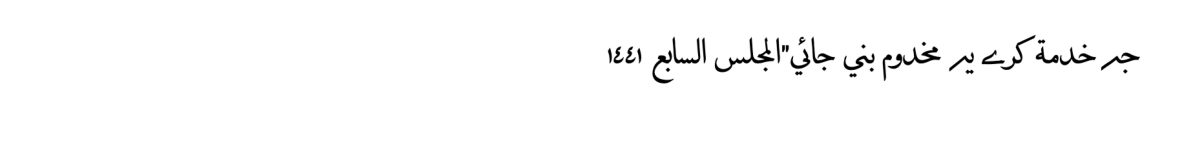

TARGET:
جھ خدمة كرے يھ مخدوم بني جائي"المجلس السابع 1441
----------------------------------------------------------------------------------------------------


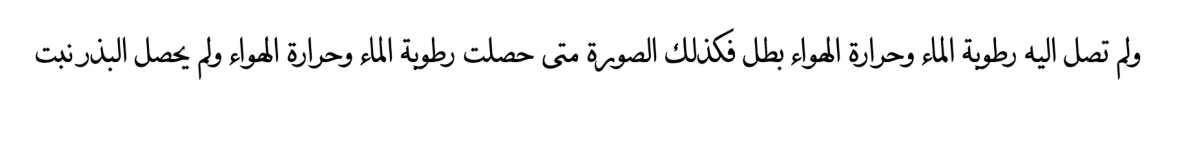

TARGET:
ولم تصل اليه رطوبة الماء وحرارة الهواء بطل فكذلك الصورة متى حصلت رطوبة الماء وحرارة الهواء ولم يحصل البذر نبت
----------------------------------------------------------------------------------------------------


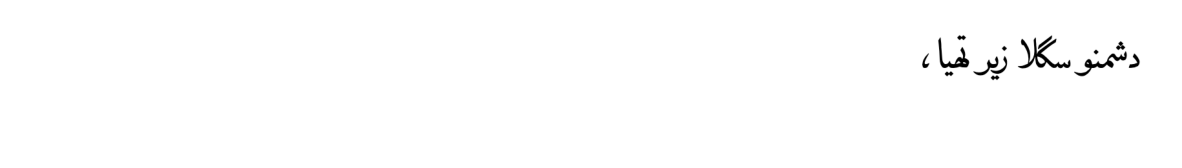

TARGET:
دشمنو سگلا زير تهيا،
----------------------------------------------------------------------------------------------------


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

for i in range(3):
    sample = small_train_dataset[i]

    image = Image.open(sample["image_path"]).convert("RGB")

    plt.figure(figsize=(15, 2.5))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    print("TARGET:")
    print(sample["target"])
    print("-" * 100)

In [ ]:
MIN_PIXELS = 256 * 28 * 28
MAX_PIXELS = 768 * 28 * 28

processor.image_processor.min_pixels = MIN_PIXELS
processor.image_processor.max_pixels = MAX_PIXELS

print("Min pixels:", processor.image_processor.min_pixels)
print("Max pixels:", processor.image_processor.max_pixels)

Min pixels: 200704
Max pixels: 602112


In [ ]:
import torch
from PIL import Image

model.eval()

@torch.inference_mode()
def transcribe_image(sample, max_new_tokens=160):

    image = Image.open(
        sample["image_path"]
    ).convert("RGB")

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image,
                },
                {
                    "type": "text",
                    "text": sample["prompt"],
                },
            ],
        }
    ]

    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )

    inputs = {
        key: value.to(model.device)
        if torch.is_tensor(value)
        else value
        for key, value in inputs.items()
    }

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
    )

    # Remove the prompt tokens.
    generated_only = generated_ids[:, inputs["input_ids"].shape[1]:]

    prediction = processor.batch_decode(
        generated_only,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]

    return prediction.strip()

In [ ]:
sample = small_train_dataset[0]

prediction = transcribe_image(sample)

print("GROUND TRUTH:")
print(repr(sample["target"]))

print("\nQWEN BASELINE:")
print(repr(prediction))

GROUND TRUTH:
'جھ خدمة كرے يھ مخدوم بني جائي"المجلس السابع 1441'

QWEN BASELINE:
'جر خدمة کرہ یہ مخدم بني جائئ"الجلس السابع ١٤١'


In [ ]:
special_index = None

for i in range(len(small_train_dataset)):
    if "\uE001" in small_train_dataset[i]["target"]:
        special_index = i
        break

print("Special sample index:", special_index)

Special sample index: 20


In [ ]:
sample = small_train_dataset[special_index]

print("GROUND TRUTH:")
print(repr(sample["target"]))

print(
    "Ground truth U+E001 count:",
    sample["target"].count("\uE001")
)

prediction = transcribe_image(sample)

print("\nBASELINE:")
print(repr(prediction))

print(
    "Prediction U+E001 count:",
    prediction.count("\uE001")
)


GROUND TRUTH:
'پچهي جيم پ\ue001لا مثال ما امر ؛'
Ground truth U+E001 count: 1

BASELINE:
'چکی جیم پهلا مثال ما امر چک'
Prediction U+E001 count: 0


In [ ]:
from jiwer import cer, wer

In [ ]:
reference = sample["target"]
hypothesis = prediction

print("CER:", cer(reference, hypothesis))
print("WER:", wer(reference, hypothesis))

CER: 0.25925925925925924
WER: 0.5714285714285714


In [ ]:
from tqdm.auto import tqdm

baseline_results = []

for i in tqdm(range(len(small_train_dataset))):

    sample = small_train_dataset[i]

    try:
        prediction = transcribe_image(sample)

        baseline_results.append({
            "index": i,
            "image": sample["image_path"],
            "target": sample["target"],
            "prediction": prediction,
        })

    except Exception as e:
        print(f"\nError on sample {i}: {e}")

        baseline_results.append({
            "index": i,
            "image": sample["image_path"],
            "target": sample["target"],
            "prediction": "",
        })

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
references = [
    x["target"]
    for x in baseline_results
]

predictions = [
    x["prediction"]
    for x in baseline_results
]

baseline_cer = cer(
    references,
    predictions
)

baseline_wer = wer(
    references,
    predictions
)

print("=" * 60)
print("BASELINE RESULTS")
print("=" * 60)

print(f"CER: {baseline_cer:.4f}")
print(f"WER: {baseline_wer:.4f}")

BASELINE RESULTS
CER: 0.3131
WER: 0.7200


In [ ]:
exact_matches = sum(
    reference == prediction
    for reference, prediction
    in zip(references, predictions)
)

exact_accuracy = (
    exact_matches
    / len(references)
)

print(
    f"Exact matches: {exact_matches}/{len(references)}"
)

print(
    f"Exact accuracy: {exact_accuracy:.2%}"
)

Exact matches: 4/100
Exact accuracy: 4.00%


In [ ]:
special_results = [
    x
    for x in baseline_results
    if "\uE001" in x["target"]
]

special_total_occurrences = sum(
    x["target"].count("\uE001")
    for x  in special_results
)

special_predicted_occurrences = sum(
    x["prediction"].count("\uE001")
    for x in special_results
)

print(
    "Special samples:",
    len(special_results)
)

print(
    "U+E001 target occurrences:",
    special_total_occurrences
)

print(
    "U+E001 predicted occurrences:",
    special_predicted_occurrences
)

Special samples: 20
U+E001 target occurrences: 24
U+E001 predicted occurrences: 0


In [ ]:
import pandas as pd

baseline_df = pd.DataFrame(
    baseline_results
)

baseline_df.to_csv(
    "/content/baseline_100.csv",
    index=False,
    encoding="utf-8-sig"
)

baseline_df.head()

,index,image,target,prediction
0,0,/content/drive/MyDrive/largelisanmodel/dataset...,"جھ خدمة كرے يھ مخدوم بني جائي""المجلس السابع 1441","جر خدمة کرہ یہ مخدم بني جائئ""الجلس السابع ١٤١"
1,1,/content/drive/MyDrive/largelisanmodel/dataset...,ولم تصل اليه رطوبة الماء وحرارة الهواء بطل فكذ...,ولم تصل إليه رطوبة الماء وحرارة الهواء بطل فكذ...
2,2,/content/drive/MyDrive/largelisanmodel/dataset...,دشمنو سگلا زير تهيا،,دشمنو سگلا زیرتیا،
3,3,/content/drive/MyDrive/largelisanmodel/dataset...,فاطمة يه مالا ليدي انے غلام نے اْزاد كري ديدا ...,فاطمة يه مالا ليدي له غلام نه ازداد كري ديدا غ...
4,4,/content/drive/MyDrive/largelisanmodel/dataset...,وضوء نے كامل كرواني سوں معنى؟,وضوء نے کامل کروائی سون معتنی؟


In [ ]:
 from PIL import Image
import torch

class QwenOCRCollator:
    def __init__(self, processor, max_length=1024):
        self.processor = processor
        self.max_length = max_length

    def __call__(self, batch):
        all_input_ids = []
        all_attention_masks = []
        all_labels = []
        all_pixel_values = []
        all_image_grid_thw = []

        for sample in batch:
            image = Image.open(
                sample["image_path"]
            ).convert("RGB")

            # Full conversation used for training
            full_messages = [
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "image",
                            "image": image,
                        },
                        {
                            "type": "text",
                            "text": sample["prompt"],
                        },
                    ],
                },
                {
                    "role": "assistant",
                    "content": [
                        {
                            "type": "text",
                            "text": sample["target"],
                        }
                    ],
                },
            ]

            # Prompt only, used to determine where assistant tokens start
            prompt_messages = [
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "image",
                            "image": image,
                        },
                        {
                            "type": "text",
                            "text": sample["prompt"],
                        },
                    ],
                }
            ]

            full_inputs = self.processor.apply_chat_template(
                full_messages,
                tokenize=True,
                add_generation_prompt=False,
                return_dict=True,
                return_tensors="pt",
            )

            prompt_inputs = self.processor.apply_chat_template(
                prompt_messages,
                tokenize=True,
                add_generation_prompt=True,
                return_dict=True,
                return_tensors="pt",
            )

            input_ids = full_inputs["input_ids"].squeeze(0)
            attention_mask = full_inputs["attention_mask"].squeeze(0)

            labels = input_ids.clone()

            prompt_length = prompt_inputs["input_ids"].shape[1]

            # Ignore user/image/prompt tokens
            labels[:prompt_length] = -100

            all_input_ids.append(input_ids)
            all_attention_masks.append(attention_mask)
            all_labels.append(labels)

            all_pixel_values.append(
                full_inputs["pixel_values"]
            )

            all_image_grid_thw.append(
                full_inputs["image_grid_thw"]
            )

        # Pad text tensors
        input_ids = torch.nn.utils.rnn.pad_sequence(
            all_input_ids,
            batch_first=True,
            padding_value=self.processor.tokenizer.pad_token_id,
        )

        attention_mask = torch.nn.utils.rnn.pad_sequence(
            all_attention_masks,
            batch_first=True,
            padding_value=0,
        )

        labels = torch.nn.utils.rnn.pad_sequence(
            all_labels,
            batch_first=True,
            padding_value=-100,
        )

        pixel_values = torch.cat(
            all_pixel_values,
            dim=0
        )

        image_grid_thw = torch.cat(
            all_image_grid_thw,
            dim=0
        )

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
            "pixel_values": pixel_values,
            "image_grid_thw": image_grid_thw,
        }


data_collator = QwenOCRCollator(
    processor=processor,
    max_length=1024,
)

In [ ]:
test_batch = data_collator(
    [small_train_dataset[0]]
)

for key, value in test_batch.items():
    print(
        key,
        value.shape,
        value.dtype
    )

input_ids torch.Size([1, 596]) torch.int64
attention_mask torch.Size([1, 596]) torch.int64
labels torch.Size([1, 596]) torch.int64
pixel_values torch.Size([2048, 1176]) torch.float32
image_grid_thw torch.Size([1, 3]) torch.int64


In [ ]:
from transformers import TrainingArguments, Trainer
import torch

training_args = TrainingArguments(
    output_dir="/content/qwen_lisan_debug_100",

    num_train_epochs=10,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,

    gradient_accumulation_steps=4,

    learning_rate=2e-4,
    weight_decay=0.01,

    # 100 samples / accumulation 4 ≈ 25 optimizer steps per epoch
    # 10 epochs ≈ 250 optimizer steps
    warmup_steps=10,

    logging_steps=1,

    eval_strategy="epoch",
    save_strategy="epoch",

    save_total_limit=2,

    fp16=(
        torch.cuda.is_available()
        and not torch.cuda.is_bf16_supported()
    ),

    bf16=(
        torch.cuda.is_available()
        and torch.cuda.is_bf16_supported()
    ),

    gradient_checkpointing=True,

    remove_unused_columns=False,

    report_to="none",
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=small_train_dataset,

    # For this first overfit test we intentionally evaluate
    # on the same 100 samples.
    eval_dataset=small_train_dataset,

    data_collator=data_collator,
)

In [ ]:
batch = data_collator([small_train_dataset[0]])

labels = batch["labels"][0]
input_ids = batch["input_ids"][0]

active_positions = labels != -100

print("Total tokens:", len(labels))
print("Tokens contributing to loss:", active_positions.sum().item())
print("Masked tokens:", (~active_positions).sum().item())

target_ids = labels[active_positions]

print("\nDecoded loss target:")
print(
    tokenizer.decode(
        target_ids,
        skip_special_tokens=True
    )
)

print("\nExpected target:")
print(
    small_train_dataset[0]["target"]
)

Total tokens: 596
Tokens contributing to loss: 28
Masked tokens: 568

Decoded loss target:
جھ خدمة كرے يھ مخدوم بني جائي"المجلس السابع 1441


Expected target:
جھ خدمة كرے يھ مخدوم بني جائي"المجلس السابع 1441


In [ ]:
ADAPTER_PATH = (
    "/content/drive/MyDrive/largelisaanmodel/"
    "qwen_lisan_debug_100_adapter"
)

model.save_pretrained(ADAPTER_PATH)
processor.save_pretrained(ADAPTER_PATH)

print("Adapter saved:", ADAPTER_PATH)

Adapter saved: /content/drive/MyDrive/largelisaanmodel/qwen_lisan_debug_100_adapter


In [ ]:
UNSEEN_SIZE = 50

unseen_records = val_records[:UNSEEN_SIZE]

unseen_dataset = QwenOCRDataset(
    unseen_records,
    PROJECT_ROOT
)

print("Unseen samples:", len(unseen_dataset))

Unseen samples: 50


In [ ]:
train_images = {
    r["messages"][0]["content"][0]["image"]
    for r in small_train_records
}

unseen_images = {
    r["messages"][0]["content"][0]["image"]
    for r in unseen_records
}

overlap = train_images & unseen_images

print("Train ↔ unseen overlap:", len(overlap))

assert len(overlap) == 0

Train ↔ unseen overlap: 0


In [ ]:
  from tqdm.auto import tqdm

unseen_results = []

model.eval()

for i in tqdm(range(len(unseen_dataset))):

    sample = unseen_dataset[i]

    prediction = transcribe_image(sample)

    unseen_results.append({
        "index": i,
        "image": sample["image_path"],
        "target": sample["target"],
        "prediction": prediction,
    })

  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
from jiwer import cer, wer

references = [
    x["target"]
    for x in unseen_results
]

predictions = [
    x["prediction"]
    for x in unseen_results
]

unseen_cer = cer(references, predictions)
unseen_wer = wer(references, predictions)

exact = sum(
    ref == pred
    for ref, pred in zip(references, predictions)
)

print("UNSEEN RESULTS")
print("----------------")
print(f"CER: {unseen_cer:.4f}")
print(f"WER: {unseen_wer:.4f}")
print(f"Exact: {exact}/{len(references)}")
print(f"Exact accuracy: {exact/len(references):.2%}")

UNSEEN RESULTS
----------------
CER: 0.1593
WER: 0.2328
Exact: 20/50
Exact accuracy: 40.00%


In [ ]:
 import random

SPECIAL_CHAR = "\uE001"

special_train = []
normal_train = []

for record in train_records:
    target = record["messages"][1]["content"][0]["text"]

    if SPECIAL_CHAR in target:
        special_train.append(record)
    else:
        normal_train.append(record)

random.seed(42)

# Approx 15% special-character samples
SPECIAL_COUNT = 75
NORMAL_COUNT = 425

train_500_records = (
    random.sample(normal_train, NORMAL_COUNT)
    + random.sample(special_train, SPECIAL_COUNT)
)

random.shuffle(train_500_records)

print("Total:", len(train_500_records))
print(
    "U+E001 samples:",
    sum(
        SPECIAL_CHAR in r["messages"][1]["content"][0]["text"]
        for r in train_500_records
    )
)

Total: 500
U+E001 samples: 75


In [ ]:
train_500_dataset = QwenOCRDataset(
    train_500_records,
    PROJECT_ROOT
)

print("Train dataset:", len(train_500_dataset))

Train dataset: 500


In [ ]:
# Do NOT train on these.
unseen_dataset = QwenOCRDataset(
    unseen_records,
    PROJECT_ROOT
)

print("Unseen validation:", len(unseen_dataset))

Unseen validation: 50


In [ ]:
CHECKPOINT_DIR = (
    "/content/drive/MyDrive/largelisanmodel/"
    "qwen_lisan_500_checkpoints"
)

In [ ]:
from transformers import TrainingArguments

training_args_500 = TrainingArguments(
    output_dir=CHECKPOINT_DIR,

    num_train_epochs=5,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,

    gradient_accumulation_steps=4,

    learning_rate=1e-4,
    weight_decay=0.01,
    warmup_steps=20,

    logging_steps=5,

    eval_strategy="epoch",

    # Save regularly to Drive
    save_strategy="steps",
    save_steps=50,
    save_total_limit=3,

    fp16=(
        torch.cuda.is_available()
        and not torch.cuda.is_bf16_supported()
    ),
    bf16=(
        torch.cuda.is_available()
        and torch.cuda.is_bf16_supported()
    ),

    gradient_checkpointing=True,
    remove_unused_columns=False,

    report_to="none",
)

In [ ]:
trainer_500 = Trainer(
    model=model,
    args=training_args_500,

    train_dataset=train_500_dataset,

    # Keep evaluation separate this time
    eval_dataset=unseen_dataset,

    data_collator=data_collator,
)

print("Trainer ready.")

Trainer ready.


In [ ]:
trainer_500.train()

Epoch,Training Loss,Validation Loss
1,0.311140,0.152847
2,0.070157,0.125569


In [ ]:
trainer_500.train(
    resume_from_checkpoint=True
)

In [ ]:

from pathlib import Path

CHECKPOINT_DIR = Path(
    "/content/drive/MyDrive/largelisaanmodel/qwen_lisan_500_checkpoints"
)

checkpoints = sorted(
    CHECKPOINT_DIR.glob("checkpoint-*"),
    key=lambda p: int(p.name.split("-")[-1])
)

print("Available checkpoints:")

for ckpt in checkpoints:
    print(ckpt)

if checkpoints:
    latest_checkpoint = checkpoints[-1]
    print("\nLatest:", latest_checkpoint)
else:
    print("No checkpoints found.")

Available checkpoints:
No checkpoints found.
